RGB A HSV

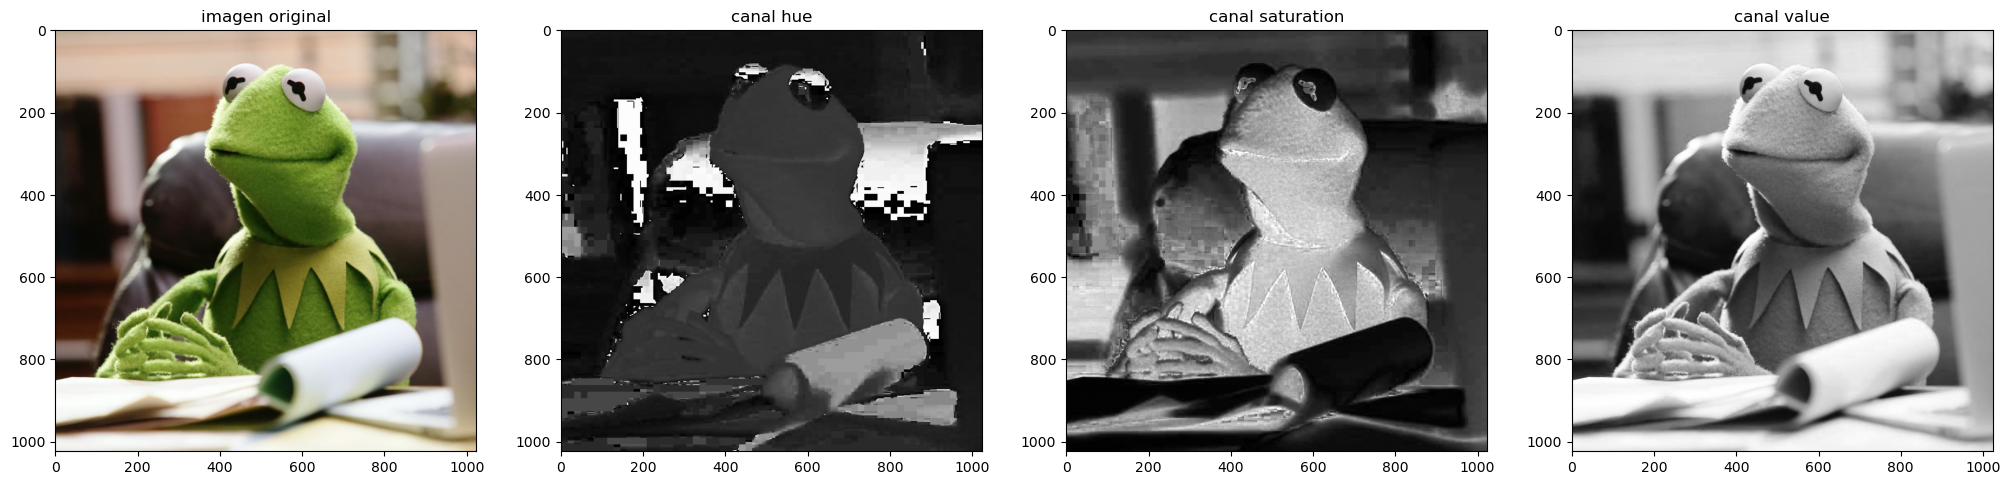

In [29]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
imagen1=cv2.imread('kermit.jpg')
img=cv2.cvtColor(imagen1, cv2.COLOR_BGR2RGB)
def RGB2HSV(img):
    img=img.astype('float32')
    img=img/255
    new_img=np.zeros_like(img)

    maxChanel=np.argmax(img, axis=2)
    maxValue=np.amax(img, axis=2)
    minChanel=np.argmin(img, axis=2)
    minValue=np.amin(img, axis=2)
    # calculo de value

    new_img[:,:,2]=maxValue
    # calculo de saturation

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if maxValue[i,j]==0:
                new_img[i,j,1]=0
            elif maxValue[i,j]!=0:
                new_img[i,j,1]=(new_img[i,j,2]-minValue[i,j])/new_img[i,j,2]
    

    # calculo de hue
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            # Si max == min (imagen en escala de grises), hue = 0
            if maxValue[i,j]==minValue[i,j]:
                new_img[i,j,0]=0
            elif maxChanel[i,j]==0:  # Canal 
                new_img[i,j,0]=60*((img[i,j,1]-img[i,j,2])/(new_img[i,j,2]-minValue[i,j]))
            elif maxChanel[i,j]==1:  # Canal verde 
                new_img[i,j,0]=120+60*(img[i,j,2]-img[i,j,0])/(new_img[i,j,2]-minValue[i,j])
            elif maxChanel[i,j]==2:  # Canal azul 
                new_img[i,j,0]=240+60*(img[i,j,0]-img[i,j,1])/(new_img[i,j,2]-minValue[i,j])
        img2=new_img[...,0]<0 
        new_img[img2,0]=new_img[img2,0]+360
    return new_img

hsv_img=RGB2HSV(img)
fig,axs=plt.subplots(1,4, figsize=(25,10))
axs[0].imshow(img)
axs[0].set_title('imagen original')
fig_img=axs[1].imshow(hsv_img[...,0], cmap='gray', vmin=0, vmax=360)
axs[1].set_title('canal hue')

fig_img=axs[2].imshow(hsv_img[...,1], cmap='gray', vmin=0, vmax=1)
axs[2].set_title('canal saturation')

fig_img=axs[3].imshow(hsv_img[...,2], cmap='gray', vmin=0, vmax=1)
axs[3].set_title('canal value')
plt.show()


Text(0.5, 1.0, 'canal value')

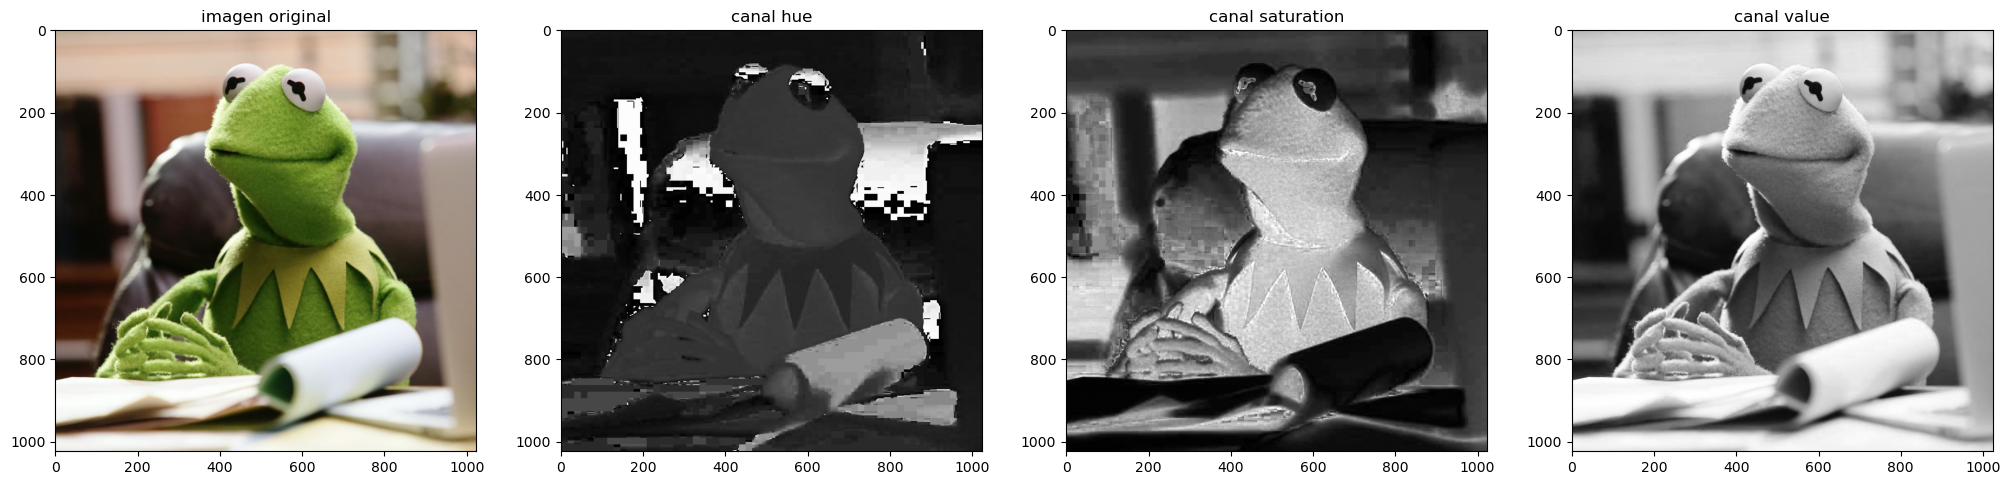

In [30]:
hsv_img_cv2= cv2.cvtColor(img, cv2.COLOR_RGB2HSV)


fig,axs=plt.subplots(1,4, figsize=(25,10))
axs[0].imshow(img)
axs[0].set_title('imagen original')
fig_img=axs[1].imshow(hsv_img[...,0], cmap='gray', vmin=0, vmax=360)
axs[1].set_title('canal hue')

fig_img=axs[2].imshow(hsv_img[...,1], cmap='gray', vmin=0, vmax=1)
axs[2].set_title('canal saturation')

fig_img=axs[3].imshow(hsv_img[...,2], cmap='gray', vmin=0, vmax=1)
axs[3].set_title('canal value')

#hsv a rgb

Text(0.5, 1.0, 'HSV1')

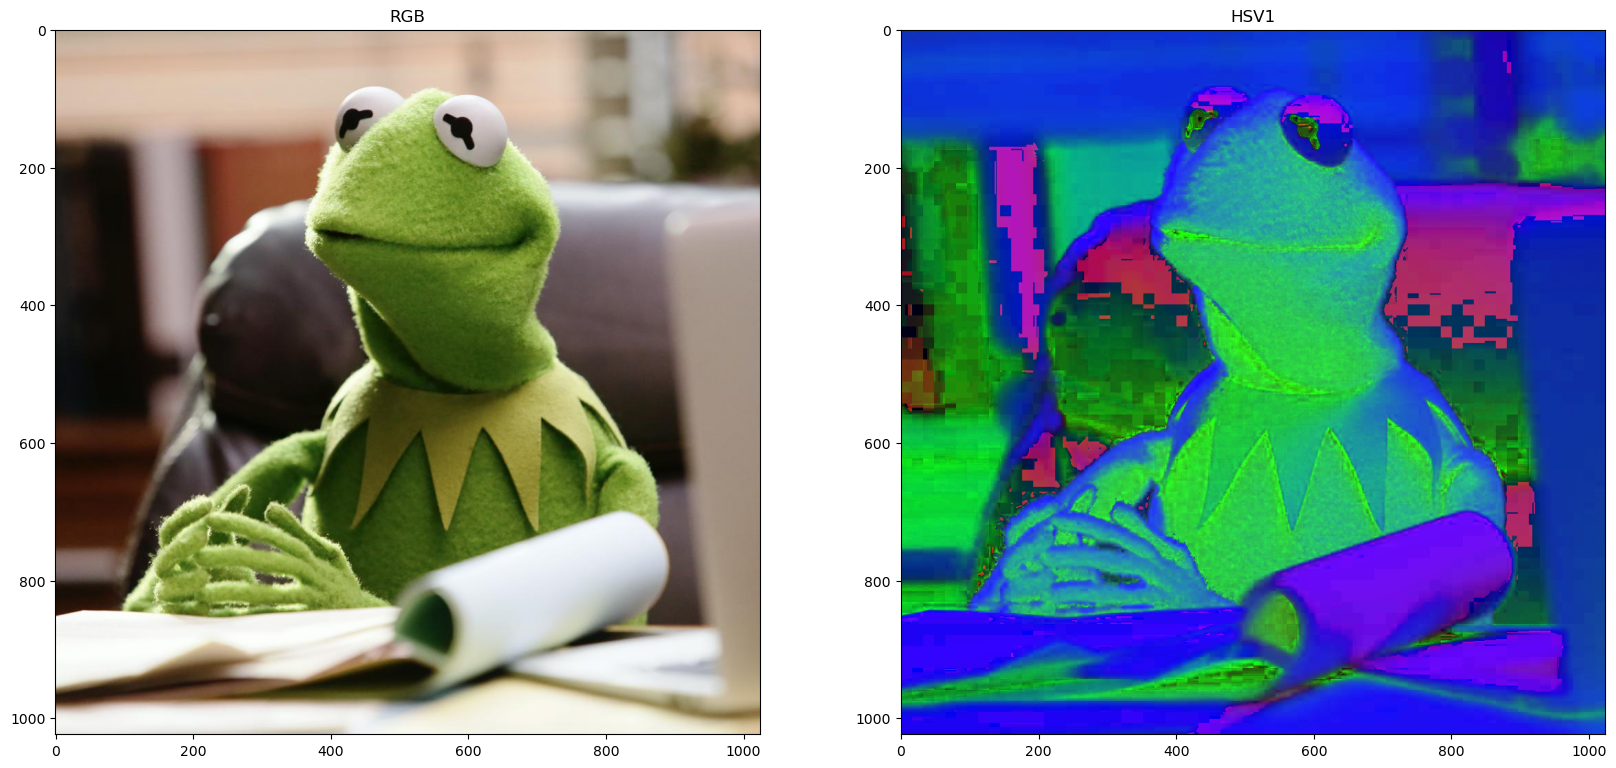

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img_rgb = cv2.cvtColor(cv2.imread('kermit.jpg', cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)

img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)

fig, axs = plt.subplots(1, 2, figsize=(20, 10))
axs[0].imshow(img_rgb)
axs[0].set_title('RGB')
axs[1].imshow(img_hsv)
axs[1].set_title('HSV1')


#hsv a rgb, con la formula xx

de Hsv a RGb, con diferentes canales, 

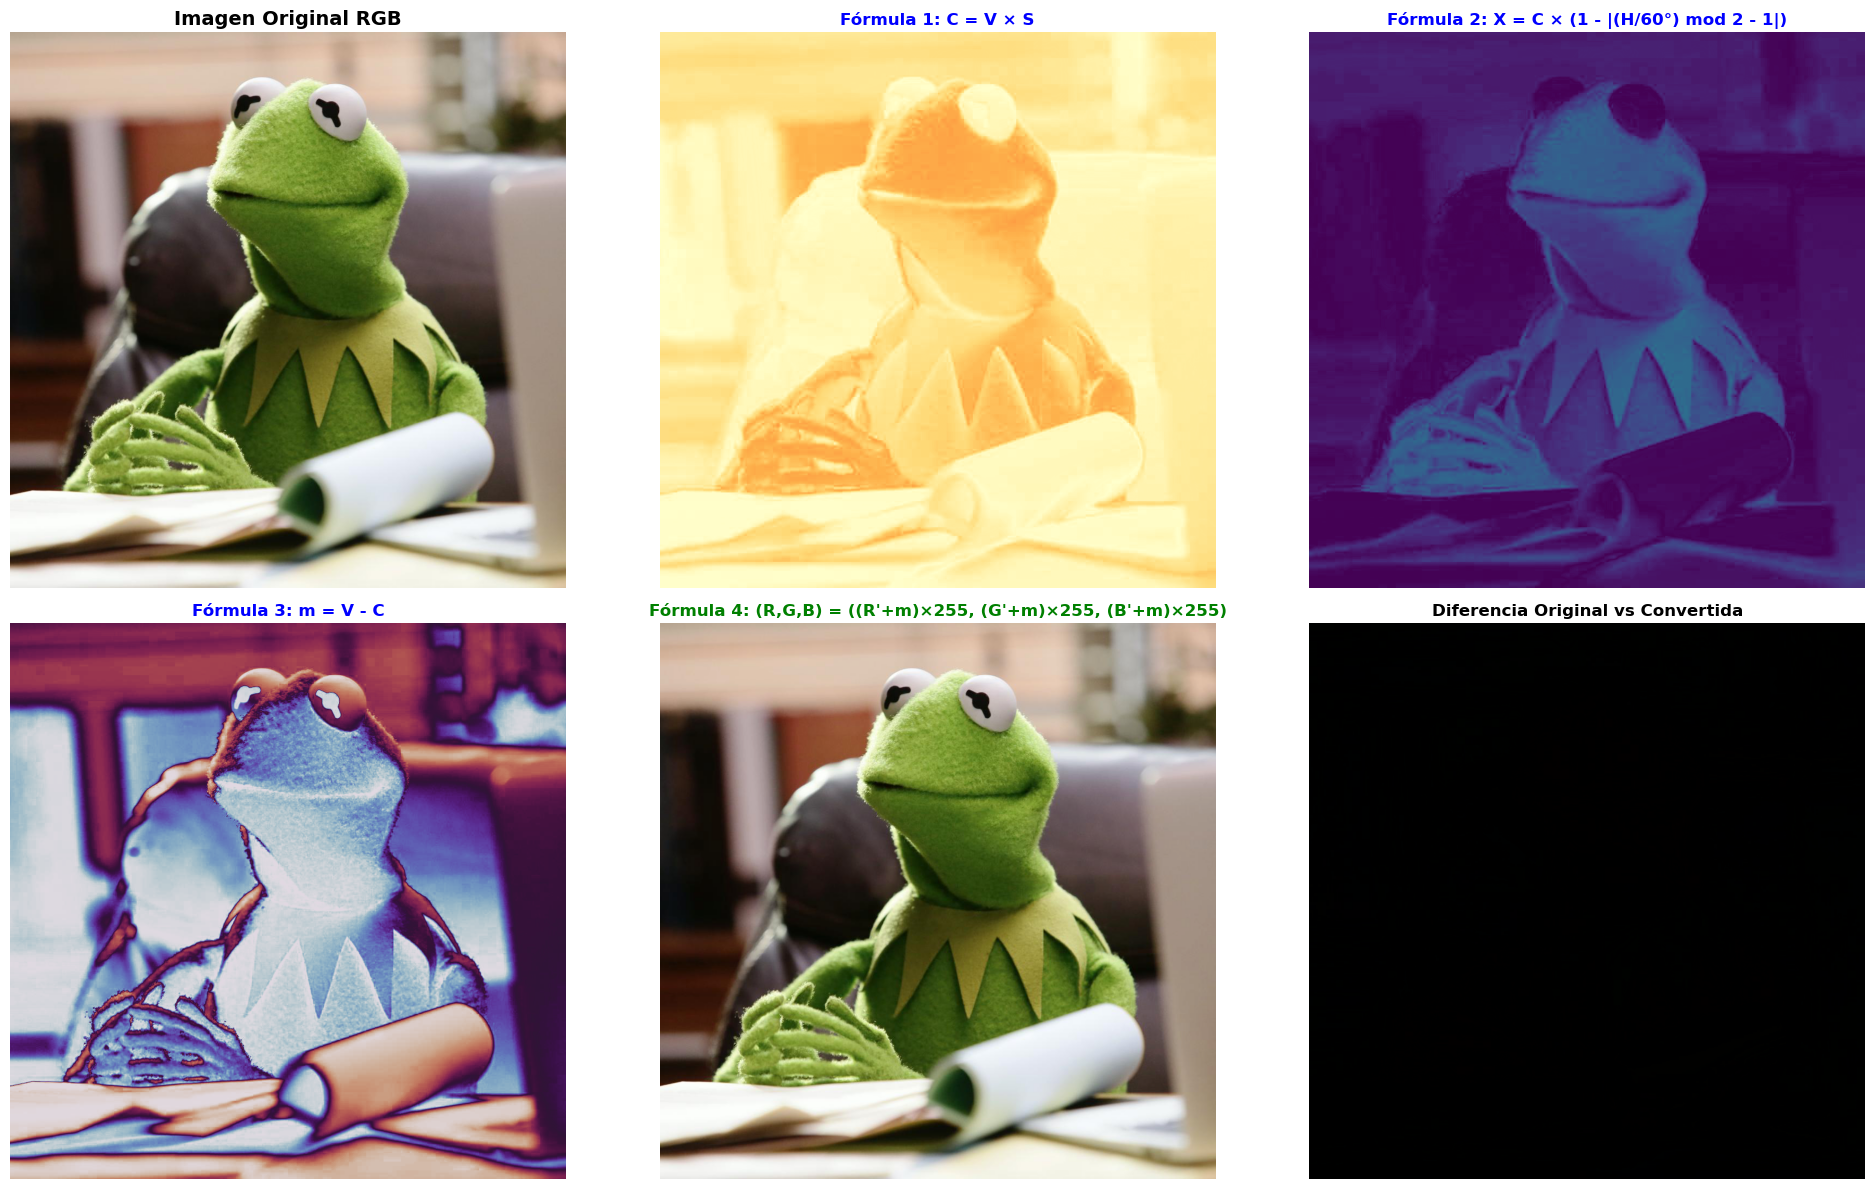

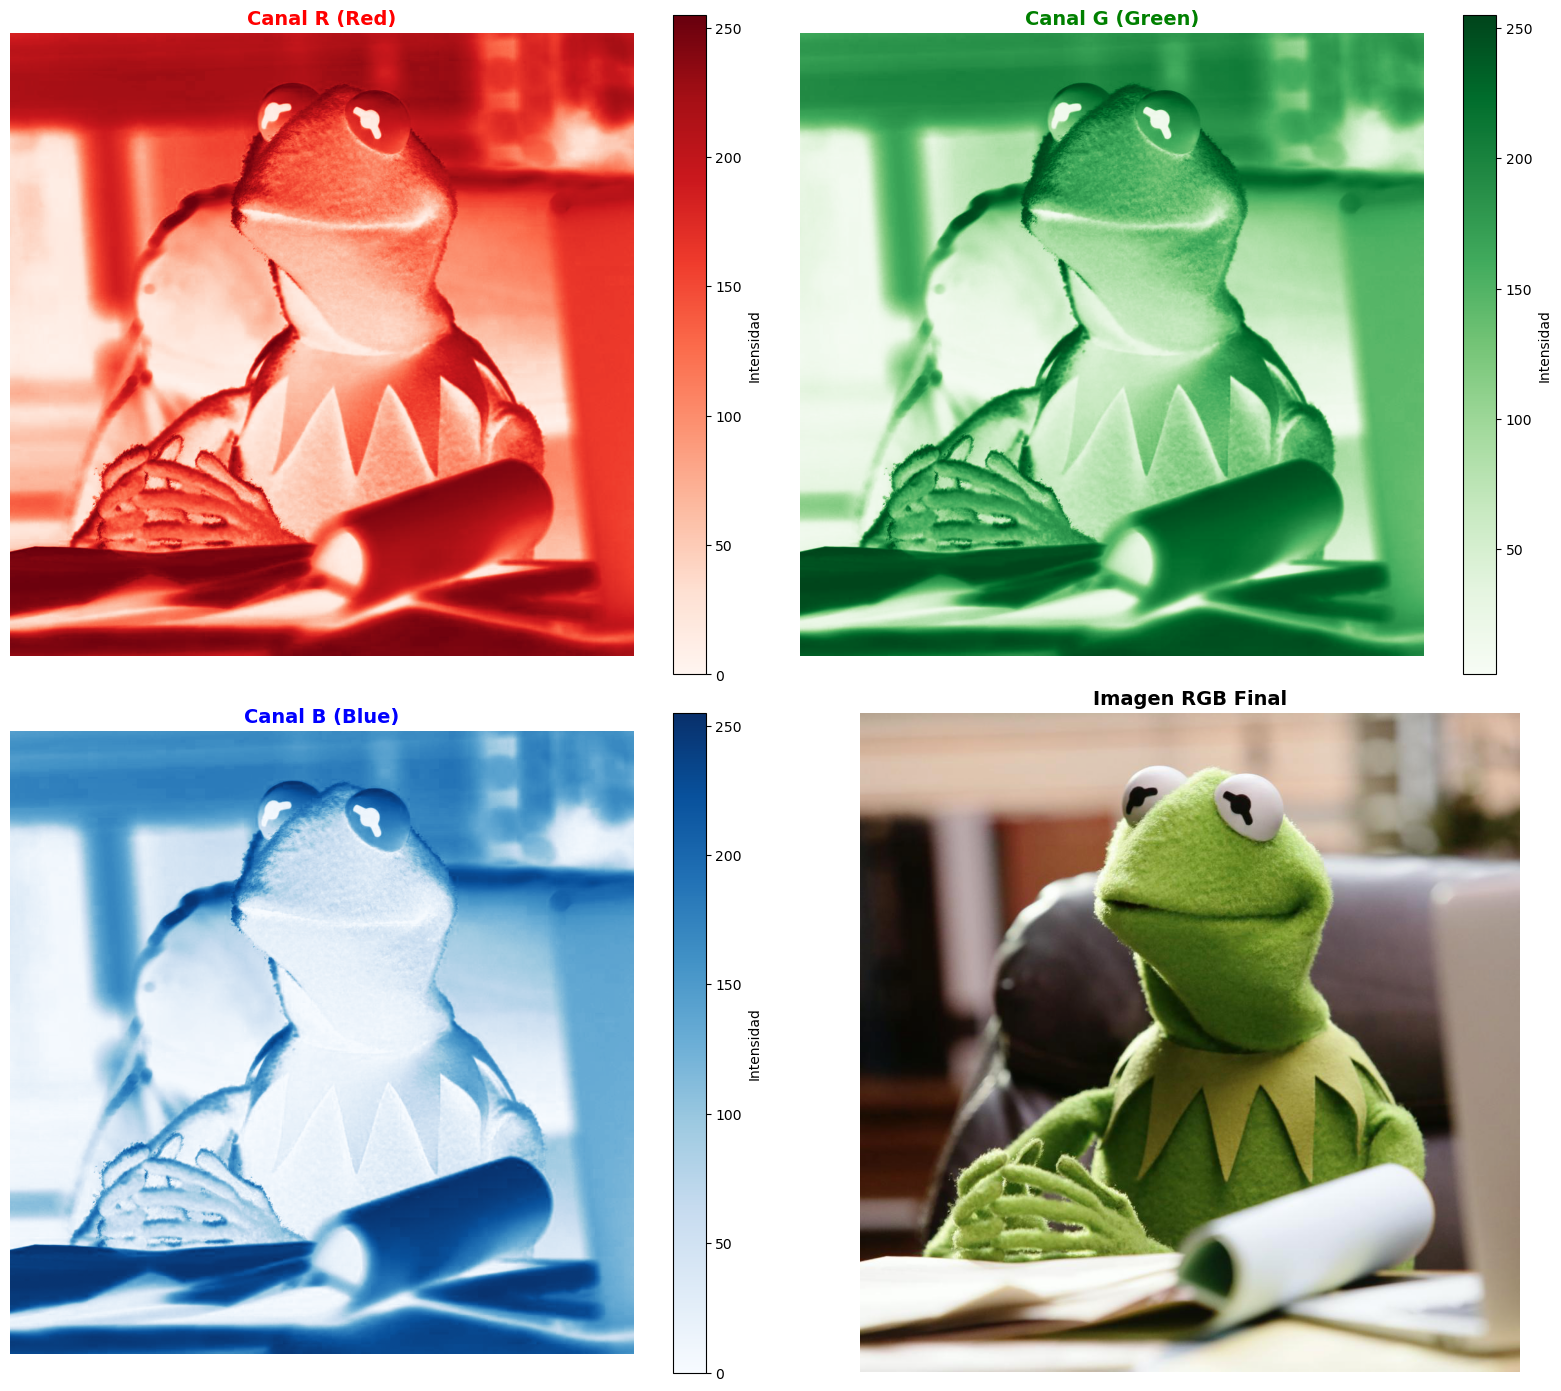

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen = cv2.imread('kermit.jpg')
imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
imagen_hsv = cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2HSV)

matricula_h = imagen_hsv[:, :, 0].astype(np.float32) * (360.0 / 180.0)
matricula_s = imagen_hsv[:, :, 1].astype(np.float32) / 255.0
matricula_v = imagen_hsv[:, :, 2].astype(np.float32) / 255.0

formula_1_c = matricula_v * matricula_s

h_60 = matricula_h / 60.0

formula_2_x = formula_1_c * (1 - np.abs((h_60 % 2) - 1))

formula_3_m = matricula_v - formula_1_c

r_prima = np.zeros_like(matricula_h)
g_prima = np.zeros_like(matricula_h)
b_prima = np.zeros_like(matricula_h)

mascara1 = (matricula_h >= 0) & (matricula_h < 60)
r_prima[mascara1] = formula_1_c[mascara1]
g_prima[mascara1] = formula_2_x[mascara1]
b_prima[mascara1] = 0

mascara2 = (matricula_h >= 60) & (matricula_h < 120)
r_prima[mascara2] = formula_2_x[mascara2]
g_prima[mascara2] = formula_1_c[mascara2]
b_prima[mascara2] = 0

mascara3 = (matricula_h >= 120) & (matricula_h < 180)
r_prima[mascara3] = 0
g_prima[mascara3] = formula_1_c[mascara3]
b_prima[mascara3] = formula_2_x[mascara3]

mascara4 = (matricula_h >= 180) & (matricula_h < 240)
r_prima[mascara4] = 0
g_prima[mascara4] = formula_2_x[mascara4]
b_prima[mascara4] = formula_1_c[mascara4]

mascara5 = (matricula_h >= 240) & (matricula_h < 300)
r_prima[mascara5] = formula_2_x[mascara5]
g_prima[mascara5] = 0
b_prima[mascara5] = formula_1_c[mascara5]

mascara6 = (matricula_h >= 300) & (matricula_h < 360)
r_prima[mascara6] = formula_1_c[mascara6]
g_prima[mascara6] = 0
b_prima[mascara6] = formula_2_x[mascara6]

canal_r = (r_prima + formula_3_m) * 255
canal_g = (g_prima + formula_3_m) * 255
canal_b = (b_prima + formula_3_m) * 255

imagen_convertida = np.stack([canal_r, canal_g, canal_b], axis=2).astype(np.uint8)

fig, axs = plt.subplots(2, 3, figsize=(20, 12))

axs[0, 0].imshow(imagen_rgb)
axs[0, 0].set_title('Imagen Original RGB', fontsize=14, fontweight='bold')
axs[0, 0].axis('off')

axs[0, 1].imshow(formula_1_c, cmap='YlOrRd', vmin=0, vmax=1)
axs[0, 1].set_title('Fórmula 1: C = V × S', fontsize=12, fontweight='bold', color='blue')
axs[0, 1].axis('off')

axs[0, 2].imshow(formula_2_x, cmap='viridis', vmin=0, vmax=1)
axs[0, 2].set_title('Fórmula 2: X = C × (1 - |(H/60°) mod 2 - 1|)', fontsize=12, fontweight='bold', color='blue')
axs[0, 2].axis('off')

axs[1, 0].imshow(formula_3_m, cmap='twilight', vmin=0, vmax=1)
axs[1, 0].set_title('Fórmula 3: m = V - C', fontsize=12, fontweight='bold', color='blue')
axs[1, 0].axis('off')

axs[1, 1].imshow(imagen_convertida)
axs[1, 1].set_title('Fórmula 4: (R,G,B) = ((R\'+m)×255, (G\'+m)×255, (B\'+m)×255)', fontsize=12, fontweight='bold', color='green')
axs[1, 1].axis('off')

diferencia = cv2.absdiff(imagen_rgb, imagen_convertida)
axs[1, 2].imshow(diferencia, cmap='hot')
axs[1, 2].set_title('Diferencia Original vs Convertida', fontsize=12, fontweight='bold')
axs[1, 2].axis('off')

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(2, 2, figsize=(16, 14))

axs[0, 0].imshow(imagen_convertida[:, :, 0], cmap='Reds')
axs[0, 0].set_title('Canal R (Red)', fontsize=14, fontweight='bold', color='red')
axs[0, 0].axis('off')
plt.colorbar(axs[0, 0].images[0], ax=axs[0, 0], label='Intensidad')

axs[0, 1].imshow(imagen_convertida[:, :, 1], cmap='Greens')
axs[0, 1].set_title('Canal G (Green)', fontsize=14, fontweight='bold', color='green')
axs[0, 1].axis('off')
plt.colorbar(axs[0, 1].images[0], ax=axs[0, 1], label='Intensidad')

axs[1, 0].imshow(imagen_convertida[:, :, 2], cmap='Blues')
axs[1, 0].set_title('Canal B (Blue)', fontsize=14, fontweight='bold', color='blue')
axs[1, 0].axis('off')
plt.colorbar(axs[1, 0].images[0], ax=axs[1, 0], label='Intensidad')

axs[1, 1].imshow(imagen_convertida)
axs[1, 1].set_title('Imagen RGB Final', fontsize=14, fontweight='bold')
axs[1, 1].axis('off')

plt.tight_layout()
plt.show()
